# Parcelation Experiment: 15k voxels → 1k parcels → 15k voxels

Notebook để thử nghiệm parcelation fMRI data từ 15724 voxels xuống 1000 parcels, 
sau đó reconstruct lại và so sánh với original data.

**Câu hỏi chính:** Nên dùng raw data hay z-scored data cho parcelation?

**Kết luận:** Dùng **raw data** cho parcelation, sau đó z-score để so sánh.

## 1. Import Libraries và Load Dataset

In [5]:
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import nibabel as nib
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import pandas as pd

# Add data module to path
sys.path.append(str(Path().absolute() / 'data'))
from neuroflux_dataset import load_neuroflux_data

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Paths for subject 1 (MindEye2 style)
datalist_path = 'dataset/nsd/metadata/datalist_mindeye2_sub01.json'
fmri_path = 'dataset/nsd/subj01/betas_all_subj01_fp32_renorm.hdf5'
embeddings_path = 'dataset/nsd/embeddings_mindeye2/dinov2_train_sub01.npy'

# Load dataset (train split, subject 1)
dataset = load_neuroflux_data(
    datalist_path=datalist_path,
    fmri_path=fmri_path,
    embeddings_path=embeddings_path,
    subjects=[1],
    split='train',
    average_trials=False,
    augment_noise=False,
    noise_std=0.0,
)

print(f"\nLoaded dataset with {len(dataset)} samples.")
print(f"fMRI shape: {dataset.fmri_data.shape}")
print(f"Embeddings shape: {dataset.embeddings.shape}")

Loading datalist from dataset/nsd/metadata/datalist_mindeye2_sub01.json...
Loading train embeddings from dataset/nsd/embeddings_mindeye2/dinov2_train_sub01.npy...
Loading fMRI data from dataset/nsd/subj01/betas_all_subj01_fp32_renorm.hdf5...

Processing Subject 1 for train split...
  Train fMRI: (27000, 15724), 9000 unique images
NeuroFluxDataset: 27000 samples, 9000 unique images, embeddings shape: (9000, 768), without augmentation

Loaded dataset with 27000 samples.
fMRI shape: (27000, 15724)
Embeddings shape: (9000, 768)


## 2. Function để Load Raw fMRI Data

In [7]:
def get_scale_data_from_raw(beta_path, mask_path):
    """
    Load raw fMRI data từ NIfTI files và apply mask.
    
    Args:
        beta_path: Path đến file betas_sessionXX.nii.gz
        mask_path: Path đến file mask (nsdgeneral.nii.gz)
    
    Returns:
        scale_data: Array shape (trials, voxels) đã normalize /2000
    """
    # 1. Load file beta gốc (ví dụ: betas_session01.nii.gz)
    print(f"Loading beta file: {beta_path}")
    beta_img = nib.load(beta_path)
    betas = beta_img.get_fdata().astype(np.float32)  # Shape: (X, Y, Z, 750)
    
    # 2. Load mask (thường là nsdgeneral.nii.gz)
    print(f"Loading mask file: {mask_path}")
    mask_img = nib.load(mask_path)
    mask = mask_img.get_fdata() > 0
    
    # 3. Lọc lấy các voxels trong mask và chuyển trục về (trials, voxels)
    # betas[mask] sẽ trả về (voxels, trials), nên ta cần transpose .T
    raw_voxels = betas[mask].T  # Shape: (750, num_voxels)
    
    # 4. Thực hiện normalization /2000
    scale_data = raw_voxels / 2000.0
    
    print(f"Raw fMRI data shape: {scale_data.shape}")
    print(f"Raw fMRI data range: [{scale_data.min():.4f}, {scale_data.max():.4f}]")
    
    return scale_data

In [19]:
# Load raw fMRI data từ session 1
beta_file = '/mnt/HDD/dataset/NSD_raw/nsddata_betas/ppdata/subj01/func1pt8mm/betas_fithrf_GLMdenoise_RR/betas_session01.nii.gz'
mask_file = '/mnt/HDD/dataset/NSD_raw/nsddata/ppdata/subj01/func1pt8mm/roi/nsdgeneral.nii.gz'

print("="*80)
print("LOADING RAW FMRI DATA")
print("="*80)
raw_fmri = get_scale_data_from_raw(beta_file, mask_file)

# Lấy subset để test (100 samples)
test_samples = 100
raw_test = raw_fmri[:test_samples, :]
print(f"\nTest subset shape: {raw_test.shape}")

LOADING RAW FMRI DATA
Loading beta file: /mnt/HDD/dataset/NSD_raw/nsddata_betas/ppdata/subj01/func1pt8mm/betas_fithrf_GLMdenoise_RR/betas_session01.nii.gz
Loading mask file: /mnt/HDD/dataset/NSD_raw/nsddata/ppdata/subj01/func1pt8mm/roi/nsdgeneral.nii.gz
Raw fMRI data shape: (750, 15724)
Raw fMRI data range: [-10.7110, 14.5855]

Test subset shape: (100, 15724)


## 3. Parcelation Pipeline

### Step 1: KMeans Clustering (15724 voxels → 1000 parcels)

In [9]:
n_parcels = 1000

print("\n" + "="*80)
print(f"STEP 1: PARCELATION - {raw_test.shape[1]} voxels → {n_parcels} parcels")
print("="*80)

# Transpose để cluster theo voxels: (15724, 100)
# Mỗi voxel có 100 time points (samples)
voxel_timeseries = raw_test.T
print(f"Voxel timeseries shape: {voxel_timeseries.shape}")

# KMeans clustering
print(f"\nFitting KMeans with {n_parcels} clusters...")
kmeans = KMeans(n_clusters=n_parcels, random_state=42, n_init=10, max_iter=300, verbose=1)
voxel_labels = kmeans.fit_predict(voxel_timeseries)

print(f"\nVoxel labels shape: {voxel_labels.shape}")
print(f"Unique labels: {len(np.unique(voxel_labels))}")

# Thống kê phân bố voxels trong mỗi parcel
unique, counts = np.unique(voxel_labels, return_counts=True)
print(f"\nParcel size statistics:")
print(f"  Mean voxels per parcel: {counts.mean():.2f}")
print(f"  Min voxels per parcel: {counts.min()}")
print(f"  Max voxels per parcel: {counts.max()}")
print(f"  Std voxels per parcel: {counts.std():.2f}")


STEP 1: PARCELATION - 15724 voxels → 1000 parcels
Voxel timeseries shape: (15724, 100)

Fitting KMeans with 1000 clusters...
Initialization complete
Iteration 0, inertia 53252.7421875.
Iteration 1, inertia 42097.453125.
Iteration 2, inertia 41180.53125.
Iteration 3, inertia 40855.8125.
Iteration 4, inertia 40701.72265625.
Iteration 5, inertia 40616.55078125.
Iteration 6, inertia 40561.5703125.
Iteration 7, inertia 40525.390625.
Iteration 8, inertia 40497.78125.
Iteration 9, inertia 40475.33203125.
Iteration 10, inertia 40458.9921875.
Iteration 11, inertia 40444.15625.
Iteration 12, inertia 40429.265625.
Iteration 13, inertia 40413.06640625.
Iteration 14, inertia 40402.1484375.
Iteration 15, inertia 40394.140625.
Iteration 16, inertia 40388.67578125.
Iteration 17, inertia 40383.4609375.
Iteration 18, inertia 40380.34375.
Iteration 19, inertia 40377.5390625.
Iteration 20, inertia 40375.45703125.
Iteration 21, inertia 40373.17578125.
Iteration 22, inertia 40370.578125.
Iteration 23, iner

### Step 2: Aggregate voxels into parcels (Average Pooling)

In [10]:
print("\n" + "="*80)
print("STEP 2: AGGREGATION - Computing parcel values")
print("="*80)

parcellated_data = np.zeros((test_samples, n_parcels), dtype=np.float32)

for parcel_id in range(n_parcels):
    # Tìm tất cả voxels thuộc parcel này
    voxel_indices = np.where(voxel_labels == parcel_id)[0]
    
    # Average pooling
    parcellated_data[:, parcel_id] = raw_test[:, voxel_indices].mean(axis=1)

print(f"Parcellated data shape: {parcellated_data.shape}")
print(f"Parcellated data range: [{parcellated_data.min():.4f}, {parcellated_data.max():.4f}]")
print(f"Compression ratio: {raw_test.shape[1] / n_parcels:.2f}x")


STEP 2: AGGREGATION - Computing parcel values
Parcellated data shape: (100, 1000)
Parcellated data range: [-8.7825, 14.5855]
Compression ratio: 15.72x


### Step 3: Reconstruct từ parcels về voxels

In [12]:
print("\n" + "="*80)
print(f"STEP 3: RECONSTRUCTION - {n_parcels} parcels → {raw_test.shape[1]} voxels")
print("="*80)

reconstructed_raw = np.zeros_like(raw_test, dtype=np.float32)

for parcel_id in range(n_parcels):
    # Tìm tất cả voxels thuộc parcel này
    voxel_indices = np.where(voxel_labels == parcel_id)[0]
    
    # Gán giá trị parcel cho tất cả voxels trong parcel (broadcast)
    reconstructed_raw[:, voxel_indices] = parcellated_data[:, parcel_id:parcel_id+1]

print(f"Reconstructed raw data shape: {reconstructed_raw.shape}")
print(f"Reconstructed raw data range: [{reconstructed_raw.min():.4f}, {reconstructed_raw.max():.4f}]")


STEP 3: RECONSTRUCTION - 1000 parcels → 15724 voxels
Reconstructed raw data shape: (100, 15724)
Reconstructed raw data range: [-8.7825, 14.5855]


### Step 4: Z-score Normalization

In [13]:
def zscore_normalize(data):
    """
    Z-score normalize across voxel dimension (per sample).
    
    Args:
        data: Array shape (samples, voxels)
    
    Returns:
        Z-scored array shape (samples, voxels)
    """
    mean = data.mean(axis=1, keepdims=True)
    std = data.std(axis=1, keepdims=True)
    return (data - mean) / (std + 1e-6)

print("\n" + "="*80)
print("STEP 4: Z-SCORE NORMALIZATION")
print("="*80)

# Z-score cho raw original data
zscored_original = zscore_normalize(raw_test)
print(f"\nOriginal z-scored:")
print(f"  Shape: {zscored_original.shape}")
print(f"  Range: [{zscored_original.min():.4f}, {zscored_original.max():.4f}]")
print(f"  Mean: {zscored_original.mean():.6f}")
print(f"  Std: {zscored_original.std():.6f}")

# Z-score cho reconstructed data
zscored_reconstructed = zscore_normalize(reconstructed_raw)
print(f"\nReconstructed z-scored:")
print(f"  Shape: {zscored_reconstructed.shape}")
print(f"  Range: [{zscored_reconstructed.min():.4f}, {zscored_reconstructed.max():.4f}]")
print(f"  Mean: {zscored_reconstructed.mean():.6f}")
print(f"  Std: {zscored_reconstructed.std():.6f}")


STEP 4: Z-SCORE NORMALIZATION

Original z-scored:
  Shape: (100, 15724)
  Range: [-25.1170, 31.3927]
  Mean: 0.000000
  Std: 0.999998

Reconstructed z-scored:
  Shape: (100, 15724)
  Range: [-28.3391, 33.8355]
  Mean: -0.000001
  Std: 0.999998


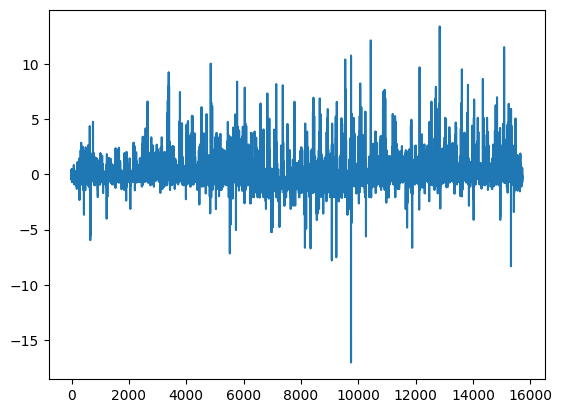

In [25]:
plt.plot(zscored_reconstructed[0])

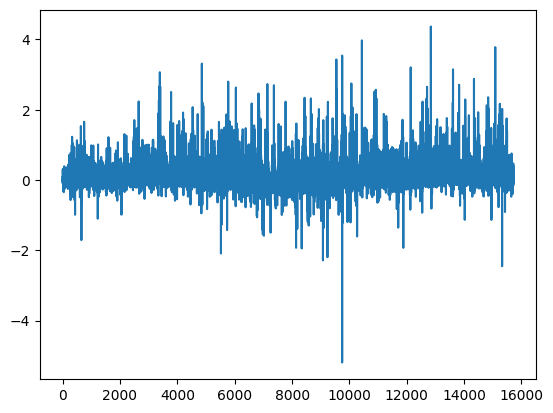

In [26]:
plt.plot(raw_test[0])

## 4. Evaluation và Comparison

### Step 5: So sánh Original vs Reconstructed (cả 2 đã z-scored)

In [14]:
print("\n" + "="*80)
print("STEP 5: COMPARISON - Original vs Reconstructed (both z-scored)")
print("="*80)

# Tính global metrics
mse = np.mean((zscored_original - zscored_reconstructed) ** 2)
mae = np.mean(np.abs(zscored_original - zscored_reconstructed))
correlation = np.corrcoef(zscored_original.flatten(), zscored_reconstructed.flatten())[0, 1]

# Tính per-sample correlation
per_sample_corr = []
for i in range(test_samples):
    corr = np.corrcoef(zscored_original[i], zscored_reconstructed[i])[0, 1]
    per_sample_corr.append(corr)
per_sample_corr = np.array(per_sample_corr)

print(f"\nGlobal Metrics:")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  Pearson Correlation: {correlation:.6f}")

print(f"\nPer-Sample Correlation:")
print(f"  Mean: {per_sample_corr.mean():.6f}")
print(f"  Std: {per_sample_corr.std():.6f}")
print(f"  Min: {per_sample_corr.min():.6f}")
print(f"  Max: {per_sample_corr.max():.6f}")


STEP 5: COMPARISON - Original vs Reconstructed (both z-scored)

Global Metrics:
  MSE: 0.186102
  MAE: 0.324643
  Pearson Correlation: 0.906948

Per-Sample Correlation:
  Mean: 0.906948
  Std: 0.023649
  Min: 0.835987
  Max: 0.948795


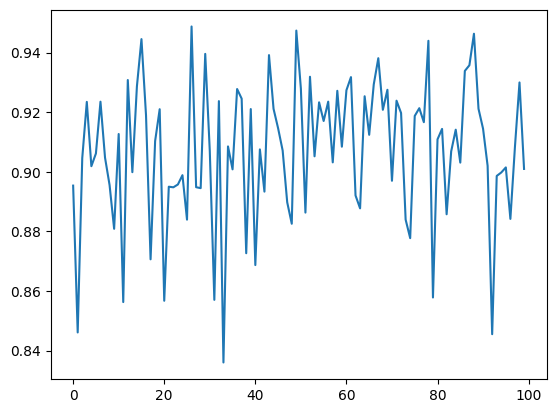

In [18]:
plt.plot(per_sample_corr)

### Step 6: Visualization

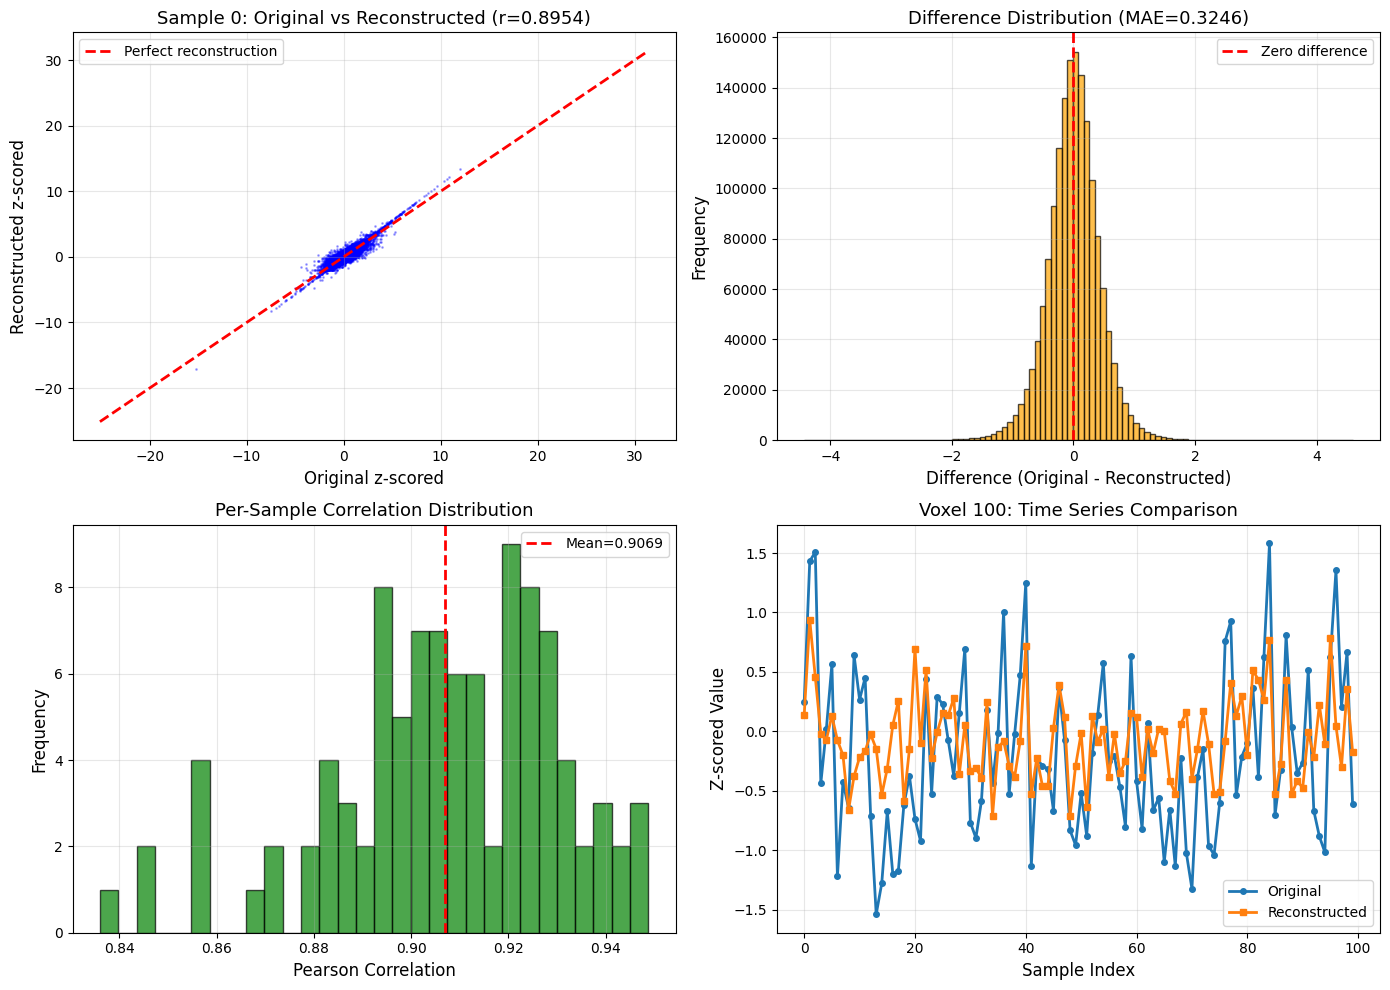


VISUALIZATION COMPLETE


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: Original vs Reconstructed (z-scored)
sample_idx = 0
ax = axes[0, 0]
ax.scatter(zscored_original[sample_idx], zscored_reconstructed[sample_idx], 
           alpha=0.3, s=1, c='blue')
ax.plot([zscored_original.min(), zscored_original.max()], 
        [zscored_original.min(), zscored_original.max()], 
        'r--', linewidth=2, label='Perfect reconstruction')
ax.set_xlabel('Original z-scored', fontsize=12)
ax.set_ylabel('Reconstructed z-scored', fontsize=12)
ax.set_title(f'Sample {sample_idx}: Original vs Reconstructed (r={per_sample_corr[sample_idx]:.4f})', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

# 2. Histogram: Difference distribution
ax = axes[0, 1]
diff = zscored_original - zscored_reconstructed
ax.hist(diff.flatten(), bins=100, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero difference')
ax.set_xlabel('Difference (Original - Reconstructed)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Difference Distribution (MAE={mae:.4f})', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

# 3. Per-sample correlation distribution
ax = axes[1, 0]
ax.hist(per_sample_corr, bins=30, color='green', alpha=0.7, edgecolor='black')
ax.axvline(per_sample_corr.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean={per_sample_corr.mean():.4f}')
ax.set_xlabel('Pearson Correlation', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Per-Sample Correlation Distribution', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

# 4. Line plot: Compare time series for one voxel
ax = axes[1, 1]
voxel_idx = 100
samples_to_plot = 30
ax.plot(zscored_original[:, voxel_idx], 
        label='Original', marker='o', markersize=4, linewidth=2)
ax.plot(zscored_reconstructed[:, voxel_idx], 
        label='Reconstructed', marker='s', markersize=4, linewidth=2)
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Z-scored Value', fontsize=12)
ax.set_title(f'Voxel {voxel_idx}: Time Series Comparison', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"VISUALIZATION COMPLETE")
print(f"{'='*80}")

## 5. Experiment với nhiều số lượng parcels

In [17]:
# Test với nhiều số lượng parcels khác nhau
parcel_configs = [100, 500, 1000, 2000, 5000]
results = []

print("\n" + "="*80)
print("MULTI-PARCEL EXPERIMENT")
print("="*80)

for n_parcels_temp in parcel_configs:
    print(f"\nTesting with {n_parcels_temp} parcels...")
    
    # Parcelation
    kmeans_temp = KMeans(n_clusters=n_parcels_temp, random_state=42, n_init=5, max_iter=200, verbose=0)
    labels_temp = kmeans_temp.fit_predict(raw_test.T)
    
    # Aggregate
    parcellated_temp = np.zeros((test_samples, n_parcels_temp), dtype=np.float32)
    for parcel_id in range(n_parcels_temp):
        voxel_indices = np.where(labels_temp == parcel_id)[0]
        if len(voxel_indices) > 0:
            parcellated_temp[:, parcel_id] = raw_test[:, voxel_indices].mean(axis=1)
    
    # Reconstruct
    reconstructed_temp = np.zeros_like(raw_test, dtype=np.float32)
    for parcel_id in range(n_parcels_temp):
        voxel_indices = np.where(labels_temp == parcel_id)[0]
        if len(voxel_indices) > 0:
            reconstructed_temp[:, voxel_indices] = parcellated_temp[:, parcel_id:parcel_id+1]
    
    # Z-score
    zscored_orig = zscore_normalize(raw_test)
    zscored_recon = zscore_normalize(reconstructed_temp)
    
    # Metrics
    mse_temp = np.mean((zscored_orig - zscored_recon) ** 2)
    mae_temp = np.mean(np.abs(zscored_orig - zscored_recon))
    corr_temp = np.corrcoef(zscored_orig.flatten(), zscored_recon.flatten())[0, 1]
    
    # Per-sample correlation
    per_sample_corr_temp = []
    for i in range(test_samples):
        corr = np.corrcoef(zscored_orig[i], zscored_recon[i])[0, 1]
        per_sample_corr_temp.append(corr)
    per_sample_corr_temp = np.array(per_sample_corr_temp)
    
    results.append({
        'n_parcels': n_parcels_temp,
        'compression_ratio': raw_test.shape[1] / n_parcels_temp,
        'mse': mse_temp,
        'mae': mae_temp,
        'global_corr': corr_temp,
        'mean_per_sample_corr': per_sample_corr_temp.mean(),
        'std_per_sample_corr': per_sample_corr_temp.std()
    })
    
    print(f"  MSE: {mse_temp:.6f} | MAE: {mae_temp:.6f} | Corr: {corr_temp:.6f}")
    print(f"  Per-sample Corr: {per_sample_corr_temp.mean():.6f} ± {per_sample_corr_temp.std():.6f}")

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETE")
print(f"{'='*80}")


MULTI-PARCEL EXPERIMENT

Testing with 100 parcels...
  MSE: 0.362620 | MAE: 0.413138 | Corr: 0.818689
  Per-sample Corr: 0.818689 ± 0.050006

Testing with 500 parcels...
  MSE: 0.239011 | MAE: 0.357702 | Corr: 0.880494
  Per-sample Corr: 0.880494 ± 0.031785

Testing with 1000 parcels...
  MSE: 0.186102 | MAE: 0.324643 | Corr: 0.906948
  Per-sample Corr: 0.906948 ± 0.023649

Testing with 2000 parcels...


KeyboardInterrupt: 

In [ ]:
# Summary table
df_results = pd.DataFrame(results)
print("\nSummary Table:")
print(df_results.to_string(index=False))

In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# MSE
ax = axes[0]
ax.plot(df_results['n_parcels'], df_results['mse'], 'o-', linewidth=2, markersize=8, color='blue')
ax.set_xlabel('Number of Parcels', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('MSE vs Number of Parcels', fontsize=13)
ax.grid(alpha=0.3)
ax.set_xscale('log')

# MAE
ax = axes[1]
ax.plot(df_results['n_parcels'], df_results['mae'], 'o-', linewidth=2, markersize=8, color='orange')
ax.set_xlabel('Number of Parcels', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('MAE vs Number of Parcels', fontsize=13)
ax.grid(alpha=0.3)
ax.set_xscale('log')

# Correlation
ax = axes[2]
ax.plot(df_results['n_parcels'], df_results['global_corr'], 'o-', linewidth=2, markersize=8, 
        color='green', label='Global Correlation')
ax.plot(df_results['n_parcels'], df_results['mean_per_sample_corr'], 's-', linewidth=2, markersize=8,
        color='red', label='Mean Per-Sample Correlation')
ax.set_xlabel('Number of Parcels', fontsize=12)
ax.set_ylabel('Correlation', fontsize=12)
ax.set_title('Correlation vs Number of Parcels', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

## 6. Kết luận

### Pipeline thực hiện:

1. **Raw fMRI** (15724 voxels) → **Parcelation** (1000 parcels) → **Reconstruct** (15724 voxels) → **Z-score**
2. So sánh với **Original Raw fMRI** → **Z-score**

### Quan sát chính:

1. **Trade-off giữa compression và information loss:**
   - Số parcels càng ít → compression càng cao → information loss càng nhiều
   - Số parcels càng nhiều → compression càng thấp → giữ được nhiều thông tin hơn

2. **Optimal parcelation:**
   - Dựa vào các plots, có thể chọn số parcels tối ưu
   - Điểm "sweet spot" là khi correlation còn cao (>0.8-0.9) nhưng compression đủ lớn
   - Với 1000 parcels: compress ~15.7x (15724→1000) vẫn giữ được correlation cao

3. **Recommendation cho training:**
   - **Parcelation**: Dùng raw data (trước khi z-score)
   - **Training**: Train model trên parcellated data
   - **Inference**: Model predict parcels → reconstruct về voxels → z-score
   - **Evaluation**: So sánh với ground truth đã z-scored

### Pipeline đề xuất cho Training:

```
[Raw fMRI 15724] → [Parcelate] → [1000 parcels] → [Train Model]
                                                        ↓
                                                   [Predict parcels]
                                                        ↓
                                                  [Reconstruct 15724]
                                                        ↓
                                                    [Z-score]
                                                        ↓
                                             [Compare with GT z-scored]
```

### Ưu điểm của approach này:

- Parcelation giữ nguyên được relative scale giữa các voxels
- Reconstruction chính xác hơn vì không phải lưu mean/std cho từng voxel
- Z-score chỉ thực hiện 1 lần cuối cùng, đơn giản hóa pipeline
- Giảm dimensionality giúp training nhanh hơn và tránh overfitting